# Chapter 2.3: Wide & Deep Learning

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain the **memorization vs generalization** tradeoff in recommendation systems
2. Describe Google's **Wide & Deep** architecture (Cheng et al., 2016)
3. Implement the **wide component** with cross-product feature transformations
4. Implement the **deep component** with embeddings and MLP layers
5. Build a **joint training** framework combining both components
6. Compare wide-only, deep-only, and joint Wide & Deep models
7. Understand when Wide & Deep outperforms individual components

## Prerequisites

- Chapters 2.1-2.2 (LR, FM fundamentals)
- PyTorch basics (nn.Module, training loops)
- Understanding of embedding layers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part2/chapter_2.3_wide_deep.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part2/chapter_2.3_wide_deep.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss

np.random.seed(42)
torch.manual_seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Memorization vs Generalization

In recommendation systems, there are two fundamental abilities:

**Memorization**: Learning the frequent co-occurrence of features and exploiting correlations in historical data. For example, if users who bought beer also bought diapers, memorize that pattern.

**Generalization**: Exploring new feature combinations that have rarely or never occurred. For example, recommending a new product to users based on similar product attributes.

| Approach | Memorization | Generalization |
|----------|:----------:|:--------------:|
| Wide (LR + crosses) | Strong | Weak |
| Deep (Embedding + MLP) | Weak | Strong |
| Wide & Deep | Strong | Strong |

> **Concept:** The Wide & Deep model (Google, 2016) combines a **wide** linear model for memorization with a **deep** neural network for generalization. It was deployed in Google Play for app recommendations, achieving significant improvement in app acquisitions.

## 2. Synthetic CTR Data with Memorization Patterns

In [2]:
def generate_wide_deep_data(n_samples=30000, seed=42):
    """
    Generate CTR data with both:
    - Memorization patterns (specific feature combinations)
    - Generalizable patterns (smooth functions of embeddings)
    """
    rng = np.random.RandomState(seed)
    
    # Field definitions
    field_dims = [10, 5, 15, 20, 8, 24]  # user, gender, ad_cat, advertiser, device, hour
    n_fields = len(field_dims)
    total_features = sum(field_dims)
    offsets = np.array([0] + list(np.cumsum(field_dims[:-1])))
    
    # Generate features
    data = np.zeros((n_samples, n_fields), dtype=np.int64)
    for f in range(n_fields):
        data[:, f] = rng.randint(0, field_dims[f], n_samples)
    
    global_data = data + offsets[np.newaxis, :]
    
    # Labels combine memorization + generalization signals
    logits = np.zeros(n_samples)
    
    # Generalization signal: smooth function of features
    true_k = 4
    true_v = rng.randn(total_features, true_k) * 0.2
    for i in range(n_samples):
        feats = global_data[i]
        v_sum = np.sum(true_v[feats], axis=0)
        logits[i] += 0.3 * np.sum(v_sum ** 2)  # Generalization
    
    # Memorization signal: specific cross-feature patterns
    memo_patterns = {}
    for _ in range(50):
        u = rng.randint(0, field_dims[0])
        c = rng.randint(0, field_dims[2])
        memo_patterns[(u, c)] = rng.choice([-1.5, 1.5])
    
    for i in range(n_samples):
        key = (data[i, 0], data[i, 2])  # (user_type, ad_category)
        if key in memo_patterns:
            logits[i] += memo_patterns[key]
    
    logits += -1.5  # Base CTR adjustment
    probs = 1.0 / (1.0 + np.exp(-logits))
    labels = rng.binomial(1, probs)
    
    print(f"Generated {n_samples} samples, CTR={labels.mean():.4f}")
    print(f"Memorization patterns: {len(memo_patterns)}")
    
    return global_data, labels, field_dims, offsets, data

global_data, labels, field_dims, offsets, raw_data = generate_wide_deep_data()
total_features = sum(field_dims)
n_fields = len(field_dims)

split = 24000
X_train, X_test = global_data[:split], global_data[split:]
X_raw_train, X_raw_test = raw_data[:split], raw_data[split:]
y_train, y_test = labels[:split], labels[split:]

Generated 30000 samples, CTR=0.2583
Memorization patterns: 44


## 3. The Wide Component

The wide component is a generalized linear model:

$$ y_{\text{wide}} = \mathbf{w}_{\text{wide}}^T [\mathbf{x}, \phi(\mathbf{x})] + b $$

where $\phi(\mathbf{x})$ are **cross-product transformations**:

$$ \phi_k(\mathbf{x}) = \prod_{i=1}^{d} x_i^{c_{k,i}} \quad c_{k,i} \in \{0, 1\} $$

For categorical features, this means creating a new feature for specific combinations, e.g., `user_type=young AND ad_category=tech`.

> **Pro Tip:** In practice, only a few important cross features are manually selected for the wide component based on domain knowledge. Not all possible crosses are used.

In [3]:
def create_cross_features(raw_data, field_dims, cross_pairs):
    """
    Create cross-product features.
    cross_pairs: list of (field_i, field_j) tuples to cross.
    Returns: integer indices into a cross feature space.
    """
    n_samples = raw_data.shape[0]
    cross_features = []
    cross_dims = []
    
    for fi, fj in cross_pairs:
        cross_dim = field_dims[fi] * field_dims[fj]
        cross_dims.append(cross_dim)
        cross_idx = raw_data[:, fi] * field_dims[fj] + raw_data[:, fj]
        cross_features.append(cross_idx)
    
    cross_data = np.stack(cross_features, axis=1)  # (n_samples, n_crosses)
    
    # Add offsets to make global indices
    cross_offsets = np.array([0] + list(np.cumsum(cross_dims[:-1])))
    cross_data_global = cross_data + cross_offsets[np.newaxis, :]
    total_cross_features = sum(cross_dims)
    
    return cross_data_global, total_cross_features, cross_dims

# Cross pairs: (user_type x ad_category), (user_type x device), (ad_cat x hour)
cross_pairs = [(0, 2), (0, 4), (2, 5)]

cross_train, total_cross_feat, cross_dims = create_cross_features(
    X_raw_train, field_dims, cross_pairs)
cross_test, _, _ = create_cross_features(
    X_raw_test, field_dims, cross_pairs)

print(f"Cross feature dimensions: {cross_dims}")
print(f"Total cross features: {total_cross_feat}")
print(f"Cross data shape: {cross_train.shape}")

Cross feature dimensions: [150, 80, 360]
Total cross features: 590
Cross data shape: (24000, 3)


## 4. The Deep Component

The deep component is an embedding + MLP:

$$ \mathbf{a}^{(l+1)} = \text{ReLU}(\mathbf{W}^{(l)} \mathbf{a}^{(l)} + \mathbf{b}^{(l)}) $$

The input is the concatenation of all field embeddings:

$$ \mathbf{a}^{(0)} = [\mathbf{e}_1, \mathbf{e}_2, \ldots, \mathbf{e}_F] $$

where $\mathbf{e}_f$ is the embedding for the active feature in field $f$.

In [4]:
class WideModel(nn.Module):
    """Wide component: linear model with cross features."""
    
    def __init__(self, num_features, num_cross_features):
        super().__init__()
        self.linear = nn.Embedding(num_features, 1)
        self.cross_linear = nn.Embedding(num_cross_features, 1)
        self.bias = nn.Parameter(torch.zeros(1))
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.xavier_uniform_(self.cross_linear.weight)
    
    def forward(self, x, x_cross):
        """x: (batch, n_fields), x_cross: (batch, n_crosses)"""
        out = self.bias.expand(x.size(0))
        out = out + self.linear(x).squeeze(-1).sum(dim=1)
        out = out + self.cross_linear(x_cross).squeeze(-1).sum(dim=1)
        return out


class DeepModel(nn.Module):
    """Deep component: embeddings + MLP."""
    
    def __init__(self, num_features, embedding_dim=8, hidden_dims=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [128, 64, 32]
        
        self.embedding = nn.Embedding(num_features, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)
        
        # MLP layers
        input_dim = 6 * embedding_dim  # 6 fields
        layers = []
        for h_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))
            input_dim = h_dim
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, x):
        """x: (batch, n_fields)"""
        embed = self.embedding(x)  # (batch, n_fields, emb_dim)
        embed_flat = embed.view(x.size(0), -1)  # (batch, n_fields * emb_dim)
        return self.mlp(embed_flat).squeeze(-1)


class WideAndDeep(nn.Module):
    """Wide & Deep model (Google, 2016)."""
    
    def __init__(self, num_features, num_cross_features, 
                 embedding_dim=8, hidden_dims=None):
        super().__init__()
        self.wide = WideModel(num_features, num_cross_features)
        self.deep = DeepModel(num_features, embedding_dim, hidden_dims)
    
    def forward(self, x, x_cross):
        wide_out = self.wide(x, x_cross)
        deep_out = self.deep(x)
        return wide_out + deep_out  # Joint prediction

print("Models defined successfully.")

Models defined successfully.


In [5]:
def train_wide_deep(model, X_train, X_cross_train, y_train,
                    X_test, X_cross_test, y_test,
                    epochs=25, batch_size=256, lr=0.001, model_type='wide_deep'):
    """Generic training function for Wide, Deep, and Wide&Deep models."""
    
    train_ds = TensorDataset(
        torch.LongTensor(X_train),
        torch.LongTensor(X_cross_train),
        torch.FloatTensor(y_train)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()
    
    history = {'train_loss': [], 'test_loss': [], 'test_auc': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        n_batches = 0
        
        for bx, bcross, by in train_loader:
            optimizer.zero_grad()
            if model_type == 'wide':
                logits = model(bx, bcross)
            elif model_type == 'deep':
                logits = model(bx)
            else:
                logits = model(bx, bcross)
            
            loss = criterion(logits, by)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        
        avg_loss = total_loss / n_batches
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            tx = torch.LongTensor(X_test)
            tcross = torch.LongTensor(X_cross_test)
            if model_type == 'wide':
                test_logits = model(tx, tcross)
            elif model_type == 'deep':
                test_logits = model(tx)
            else:
                test_logits = model(tx, tcross)
            
            test_probs = torch.sigmoid(test_logits).numpy()
            test_logloss = log_loss(y_test, test_probs)
            test_auc = roc_auc_score(y_test, test_probs)
        
        history['train_loss'].append(avg_loss)
        history['test_loss'].append(test_logloss)
        history['test_auc'].append(test_auc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, "
                  f"test_loss={test_logloss:.4f}, AUC={test_auc:.4f}")
    
    return history

In [6]:
# Train Wide-only
print("=== Wide Model (Memorization) ===")
torch.manual_seed(42)
wide_model = WideModel(total_features, total_cross_feat)
wide_history = train_wide_deep(
    wide_model, X_train, cross_train, y_train,
    X_test, cross_test, y_test, epochs=25, model_type='wide')

=== Wide Model (Memorization) ===


Epoch 5: train_loss=0.5498, test_loss=0.5561, AUC=0.6265


Epoch 10: train_loss=0.5306, test_loss=0.5438, AUC=0.6590


Epoch 15: train_loss=0.5205, test_loss=0.5382, AUC=0.6661


Epoch 20: train_loss=0.5146, test_loss=0.5352, AUC=0.6690


Epoch 25: train_loss=0.5109, test_loss=0.5337, AUC=0.6699


In [7]:
# Train Deep-only
print("=== Deep Model (Generalization) ===")
torch.manual_seed(42)
deep_model = DeepModel(total_features, embedding_dim=8, hidden_dims=[128, 64, 32])
deep_history = train_wide_deep(
    deep_model, X_train, cross_train, y_train,
    X_test, cross_test, y_test, epochs=25, model_type='deep')

=== Deep Model (Generalization) ===


Epoch 5: train_loss=0.5536, test_loss=0.5622, AUC=0.6079


Epoch 10: train_loss=0.5211, test_loss=0.5421, AUC=0.6552


Epoch 15: train_loss=0.5063, test_loss=0.5440, AUC=0.6590


Epoch 20: train_loss=0.4941, test_loss=0.5532, AUC=0.6570


Epoch 25: train_loss=0.4852, test_loss=0.5570, AUC=0.6552


In [8]:
# Train Wide & Deep (Joint)
print("=== Wide & Deep (Joint) ===")
torch.manual_seed(42)
wd_model = WideAndDeep(total_features, total_cross_feat, 
                        embedding_dim=8, hidden_dims=[128, 64, 32])
wd_history = train_wide_deep(
    wd_model, X_train, cross_train, y_train,
    X_test, cross_test, y_test, epochs=25, model_type='wide_deep')

=== Wide & Deep (Joint) ===


Epoch 5: train_loss=0.5393, test_loss=0.5496, AUC=0.6433


Epoch 10: train_loss=0.5093, test_loss=0.5413, AUC=0.6618


Epoch 15: train_loss=0.4917, test_loss=0.5455, AUC=0.6620


Epoch 20: train_loss=0.4795, test_loss=0.5534, AUC=0.6608


Epoch 25: train_loss=0.4686, test_loss=0.5570, AUC=0.6576


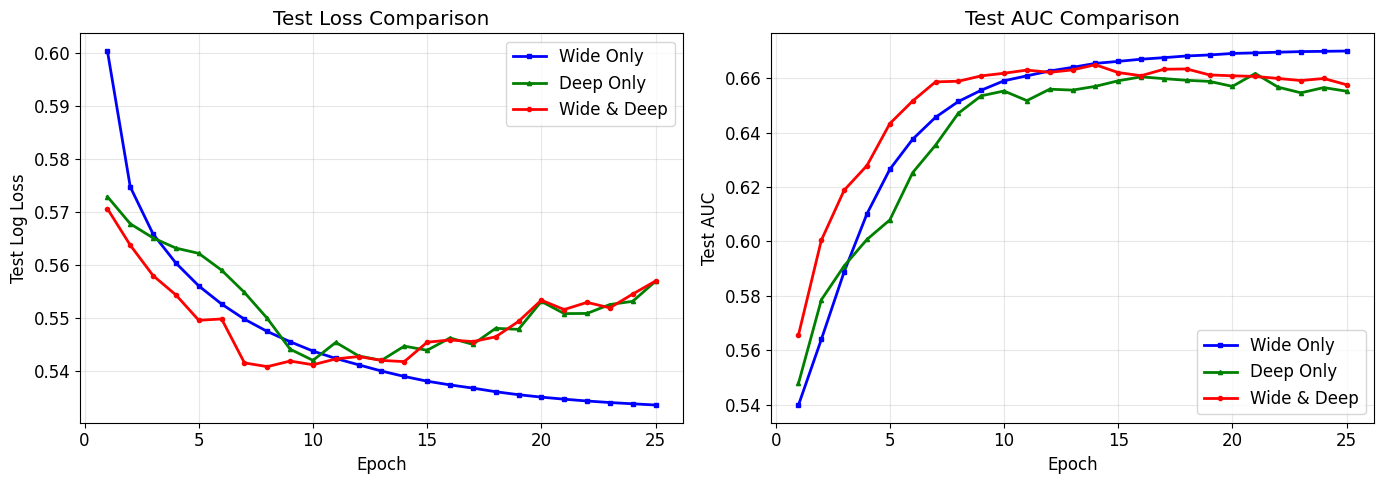


Final AUC - Wide: 0.6699, Deep: 0.6552, W&D: 0.6576


In [9]:
# Compare all three
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, 26)

axes[0].plot(epochs, wide_history['test_loss'], 'b-s', label='Wide Only', linewidth=2, markersize=3)
axes[0].plot(epochs, deep_history['test_loss'], 'g-^', label='Deep Only', linewidth=2, markersize=3)
axes[0].plot(epochs, wd_history['test_loss'], 'r-o', label='Wide & Deep', linewidth=2, markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Log Loss')
axes[0].set_title('Test Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, wide_history['test_auc'], 'b-s', label='Wide Only', linewidth=2, markersize=3)
axes[1].plot(epochs, deep_history['test_auc'], 'g-^', label='Deep Only', linewidth=2, markersize=3)
axes[1].plot(epochs, wd_history['test_auc'], 'r-o', label='Wide & Deep', linewidth=2, markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test AUC')
axes[1].set_title('Test AUC Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal AUC - Wide: {wide_history['test_auc'][-1]:.4f}, "
      f"Deep: {deep_history['test_auc'][-1]:.4f}, "
      f"W&D: {wd_history['test_auc'][-1]:.4f}")

## 5. Joint Training vs Ensemble

The original paper emphasizes **joint training** over ensemble:

- **Joint training**: Wide and Deep are trained simultaneously, with gradients flowing through both. The wide side only needs to complement the deep side, so it can be smaller.
- **Ensemble**: Wide and Deep are trained independently, then predictions are combined. Each model must be full-sized.

In joint training, the final prediction is:

$$ P(y=1|\mathbf{x}) = \sigma\left(\mathbf{w}_{\text{wide}}^T[\mathbf{x}, \phi(\mathbf{x})] + \mathbf{w}_{\text{deep}}^T \mathbf{a}^{(l_f)} + b\right) $$

> **Common Pitfall:** A common mistake is to train the wide and deep parts with different optimizers or learning rates without careful tuning. In practice, the wide part often uses FTRL while the deep part uses AdaGrad or Adam.

In [10]:
# Demonstrate ensemble approach
# Use the already-trained wide and deep models
wide_model.eval()
deep_model.eval()

with torch.no_grad():
    tx = torch.LongTensor(X_test)
    tcross = torch.LongTensor(cross_test)
    
    wide_logits = wide_model(tx, tcross)
    deep_logits = deep_model(tx)
    
    # Simple ensemble: average logits
    ensemble_logits = 0.5 * wide_logits + 0.5 * deep_logits
    ensemble_probs = torch.sigmoid(ensemble_logits).numpy()
    
    ensemble_auc = roc_auc_score(y_test, ensemble_probs)

print(f"Wide-only AUC:   {wide_history['test_auc'][-1]:.4f}")
print(f"Deep-only AUC:   {deep_history['test_auc'][-1]:.4f}")
print(f"Ensemble AUC:    {ensemble_auc:.4f}")
print(f"Joint W&D AUC:   {wd_history['test_auc'][-1]:.4f}")

Wide-only AUC:   0.6699
Deep-only AUC:   0.6552
Ensemble AUC:    0.6698
Joint W&D AUC:   0.6576


## 6. Architecture Visualization

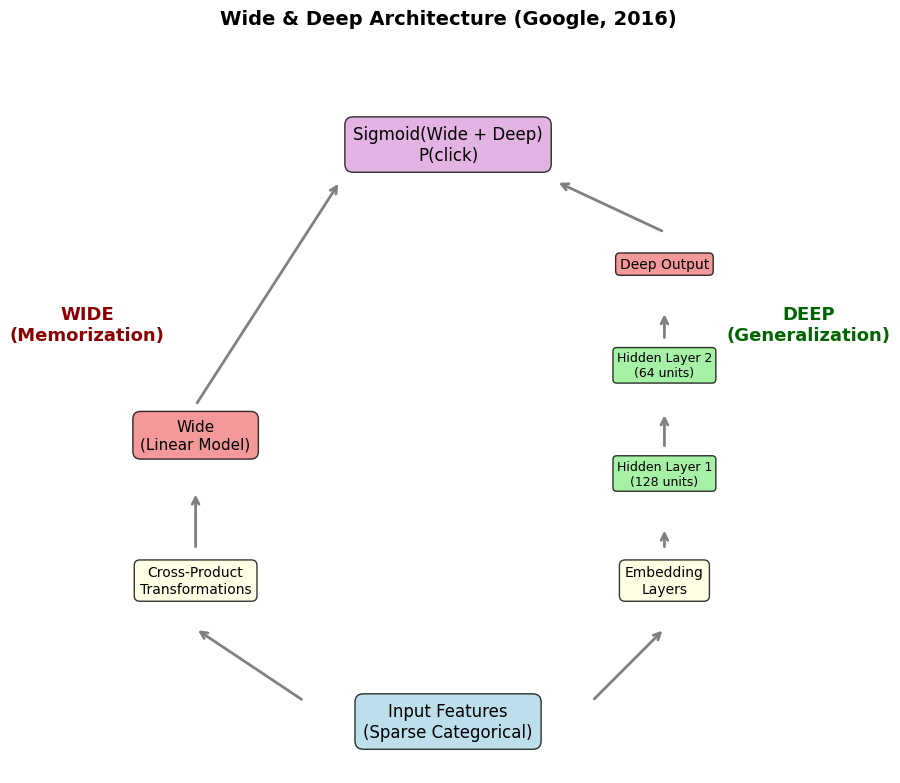

In [11]:
# Visualize the Wide & Deep architecture diagram
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')

# Input layer
ax.text(6, 0.5, 'Input Features\n(Sparse Categorical)', ha='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))

# Wide side
ax.text(2.5, 2.5, 'Cross-Product\nTransformations', ha='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))
ax.text(2.5, 4.5, 'Wide\n(Linear Model)', ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8))

# Deep side
ax.text(9, 2.5, 'Embedding\nLayers', ha='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))
ax.text(9, 4.0, 'Hidden Layer 1\n(128 units)', ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))
ax.text(9, 5.5, 'Hidden Layer 2\n(64 units)', ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))
ax.text(9, 7.0, 'Deep Output', ha='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.8))

# Output
ax.text(6, 8.5, 'Sigmoid(Wide + Deep)\nP(click)', ha='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='plum', alpha=0.8))

# Arrows
arrow_props = dict(arrowstyle='->', lw=2, color='gray')
ax.annotate('', xy=(2.5, 2.0), xytext=(4, 1.0), arrowprops=arrow_props)
ax.annotate('', xy=(9, 2.0), xytext=(8, 1.0), arrowprops=arrow_props)
ax.annotate('', xy=(2.5, 3.9), xytext=(2.5, 3.1), arrowprops=arrow_props)
ax.annotate('', xy=(9, 3.4), xytext=(9, 3.1), arrowprops=arrow_props)
ax.annotate('', xy=(9, 5.0), xytext=(9, 4.5), arrowprops=arrow_props)
ax.annotate('', xy=(9, 6.4), xytext=(9, 6.0), arrowprops=arrow_props)
ax.annotate('', xy=(4.5, 8.2), xytext=(2.5, 5.1), arrowprops=arrow_props)
ax.annotate('', xy=(7.5, 8.2), xytext=(9, 7.5), arrowprops=arrow_props)

# Labels
ax.text(1.0, 6.0, 'WIDE\n(Memorization)', ha='center', fontsize=13, fontweight='bold', color='darkred')
ax.text(11.0, 6.0, 'DEEP\n(Generalization)', ha='center', fontsize=13, fontweight='bold', color='darkgreen')

ax.set_title('Wide & Deep Architecture (Google, 2016)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1: Implement Wide & Deep with Separate Optimizers

In [12]:
# Exercise 1: Train Wide & Deep with FTRL for wide, Adam for deep
# TODO: Create separate parameter groups for wide and deep components
# TODO: Use different learning rates (e.g., wide: 0.01, deep: 0.001)
# TODO: Compare with the uniform-optimizer version

# Hint: In PyTorch, you can pass parameter groups to the optimizer:
# optimizer = optim.Adam([
#     {'params': model.wide.parameters(), 'lr': 0.01},
#     {'params': model.deep.parameters(), 'lr': 0.001},
# ])

# YOUR CODE HERE

### Exercise 2: Compare Wide & Deep with Different Cross Feature Sets

In [13]:
# Exercise 2: Ablation study on cross features
# TODO: Train Wide & Deep with:
#   a) No cross features (wide = linear only)
#   b) 1 cross pair
#   c) 3 cross pairs (current)
#   d) All possible cross pairs (6 choose 2 = 15)
# TODO: Plot AUC vs number of crosses
# TODO: Is there diminishing returns? When does adding more crosses stop helping?

# YOUR CODE HERE

### Exercise 3: Deep Component Depth Analysis

In [14]:
# Exercise 3: How does MLP depth affect the deep component?
# TODO: Train Deep models with:
#   a) 1 hidden layer [64]
#   b) 2 hidden layers [128, 64]
#   c) 3 hidden layers [256, 128, 64]
#   d) 4 hidden layers [256, 128, 64, 32]
# TODO: Plot AUC and training time vs depth
# TODO: What's the sweet spot for this dataset?

# YOUR CODE HERE

## Summary

In this chapter, we covered:

1. **Memorization vs Generalization**: Wide models memorize specific patterns; deep models generalize to unseen combinations
2. **Wide & Deep** (Google, 2016): A principled framework to combine both abilities
   - Wide: Linear model with cross-product features
   - Deep: Embedding + MLP
   - Joint training: Both components trained simultaneously
3. **Joint training** is preferred over ensemble because the components can complement each other

### Key Takeaways

- Wide & Deep typically outperforms either component alone
- The wide component needs manually engineered cross features (limitation!)
- The deep component provides generalization through learned embeddings
- This was a landmark paper that sparked the "wide + deep" paradigm in CTR prediction

### What's Next

In Chapter 2.4, we'll see how **DeepFM** eliminates the need for manual feature engineering by replacing the wide component with a Factorization Machine, and explore other deep feature interaction architectures.